# TITLE

## Infos zu Experiment:
- Zustand Zellen, Benutzte FBS Konz., Dichte der Zellen, Wartezeit etc. 

## Data Loading and Preprocessing

### Load required libraries and specify the data folder

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
import plotly.express as px
import seaborn as sns
import numpy as np
import scipy
from scipy.stats import pearsonr, spearmanr
from scipy.integrate import simpson

data_folder = "\\\\izbkingston.unibe.ch\\imaging.data\\PertzLab\\optoRTK_CedricZ\\experimental_data"
experiment_name = "2025-08-29_Random_single_stim"
exp_path = os.path.join(data_folder, experiment_name)


### Load analysed data from rtm-pymmcore experiment

This loads the data from the individual field of views and create one big dataframe. This dataframe is then saved in your local folder and used to plot the data.

### Data clean-up
Add Cytoplasma to nuclear ratio based on measured intensities. Further normalise according to the first few frames. Remove cells which were not tracked for 80% of the frames.

In [2]:
df = pd.read_parquet("exp_data.parquet")

In [3]:
df["cnr"] = df["mean_intensity_C1_ring"] / df["mean_intensity_C1_nuc"]
df["cnr_median"] = df["median_intensity_C1_ring"] / df["median_intensity_C1_nuc"]
df["uid"] = df["fov"].astype("string") + "_" + df["particle"].astype("string")
df['cell_id'] = df['cell_line'].astype(str) + '_' + df['stim_exposure'].astype(str) + 'ms_' + df['uid'].astype(str)
df["frame"] = df["timestep"]

frame_counts = df["uid"].value_counts()
threshold = 0.9 * frame_counts.max()

valid_uids = frame_counts[frame_counts >= threshold].index
df = df[df["uid"].isin(valid_uids)]

### Median

In [ ]:
NORM_UNTIL_TIMEPOINT = 10
median_cnr_first_ten_frames = df[df['frame'] < NORM_UNTIL_TIMEPOINT].groupby('uid')['cnr_median'].median()
def normalize_cnr(row):
    return row['cnr_median'] / median_cnr_first_ten_frames[row['uid']] if row['uid'] in median_cnr_first_ten_frames else np.nan
df["cnr_median_norm"] = df.apply(normalize_cnr, axis=1)
df.dropna(subset=["cnr_median_norm"], inplace=True) 

### Mean

In [4]:
NORM_UNTIL_TIMEPOINT = 10
mean_cnr_first_ten_frames = df[df['frame'] < NORM_UNTIL_TIMEPOINT].groupby('uid')['cnr'].median()
def normalize_cnr(row):
    return row['cnr'] / mean_cnr_first_ten_frames[row['uid']] if row['uid'] in mean_cnr_first_ten_frames else np.nan
df["cnr_norm"] = df.apply(normalize_cnr, axis=1)
df.dropna(subset=["cnr_norm"], inplace=True) 

In [5]:
df

,mean_intensity_C0_nuc,mean_intensity_C1_nuc,label,x,y,area,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,...,stim_channel_group,stim_channel_device_name,stim_channel_power_property_name,stim_exposure,stim,optocheck_mean_intensity,uid,cell_id,frame,cnr_norm
0,2129.046765,5241.976617,5,243.371005,645.558067,1283.0,2104.0,5124.0,845.440559,4317.940559,...,TTL_ERK,Spectra,Cyan_Level,50.0,False,306.724497,0_4,FGFR_50.0ms_0_4,0,1.199170
1,3721.901620,4977.915509,6,339.651620,193.769676,864.0,3700.5,5006.0,1122.149425,4727.015326,...,TTL_ERK,Spectra,Cyan_Level,50.0,False,310.727273,0_5,FGFR_50.0ms_0_5,0,1.000550
2,10319.730594,1386.136986,7,355.789954,906.141553,219.0,10345.0,1301.0,2121.222222,2309.029630,...,TTL_ERK,Spectra,Cyan_Level,50.0,False,734.200935,0_6,FGFR_50.0ms_0_6,0,0.997590
3,3932.953984,24478.969697,9,418.687991,567.427609,891.0,3847.0,25487.0,1284.452471,7931.418251,...,TTL_ERK,Spectra,Cyan_Level,50.0,False,422.270648,0_8,FGFR_50.0ms_0_8,0,1.025419
4,8893.149398,4228.409639,11,511.626506,877.236145,415.0,8259.0,4069.0,1649.247191,5852.443820,...,TTL_ERK,Spectra,Cyan_Level,50.0,False,558.897778,0_10,FGFR_50.0ms_0_10,0,1.002902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12061,3105.401274,5545.849257,12,495.821656,603.968153,471.0,3075.0,5559.0,865.178378,3705.113514,...,TTL_ERK,Spectra,Cyan_Level,250.0,False,438.681529,17_13,TrkA_250.0ms_17_13,719,1.056237
12062,1732.079412,423.000000,13,511.426471,962.479412,340.0,1736.0,423.0,499.654321,418.265432,...,TTL_ERK,Spectra,Cyan_Level,250.0,False,241.020588,17_9,TrkA_250.0ms_17_9,719,0.971695
12063,2873.914819,4896.021587,14,545.318553,786.685531,1714.0,2817.5,4805.5,1052.081505,6520.394984,...,TTL_ERK,Spectra,Cyan_Level,250.0,False,302.231039,17_10,TrkA_250.0ms_17_10,719,1.973687
12065,5674.005803,41430.837524,16,612.417795,514.276596,517.0,5367.0,42576.0,1758.885417,14993.723958,...,TTL_ERK,Spectra,Cyan_Level,250.0,False,1119.847195,17_14,TrkA_250.0ms_17_14,719,1.377443


Delete specific fucked-up cells

In [6]:
df_manual_filtering = pd.read_csv(os.path.join(exp_path, "cell_selection.csv"))
df_manual_filtering

,particle,label,fov,uid,selected,deleted
0,6,6,0,0_6,False,True
1,21,21,0,0_21,False,True
2,10,10,0,0_10,False,True
3,15,15,1,1_15,False,True
4,2,2,1,1_2,False,True
5,1,1,1,1_1,False,True
6,6,6,2,2_6,False,True
7,16,16,2,2_16,False,True
8,10,10,2,2_10,False,True
9,22,22,3,3_22,False,True


In [7]:
# Step 1: Get list of uids to delete
uids_to_delete = df_manual_filtering[df_manual_filtering["deleted"] == True]["uid"]

# Step 2: Remove these uids from the main dataframe
df = df[~df["uid"].isin(uids_to_delete)]
df = df[~df["uid"].astype(str).str.startswith("12")]

Calculate ERK-activity baseline for each cell_id

In [8]:
# Calculate the mean CNR for each cell_id from timestep 0 to 9
# Step 1: Filter to frames 0–9
df_0_9 = df[(df['frame'] >= 0) & (df['frame'] <= 9)].copy()

# Step 2: Group by 'cell_id' and calculate the median cnr
median_cnr = df_0_9.groupby('cell_id')['cnr'].median().reset_index()
median_cnr.rename(columns={'cnr': 'median_cnr_0_9'}, inplace=True)

# Step 3: Merge the median_cnr back into the main df
df = df.merge(median_cnr, on='cell_id', how='left')

In [9]:
df.to_parquet("data_filtered.parquet")

# CSV Export

In [8]:
df[["cell_line", "uid", "stim_power", "stim_exposure", "stim_timestep", "optocheck_mean_intensity", "timestep", "cnr", "cnr_median", "cnr_norm"]].to_csv("filtered_data.csv", index=False)

## Results

In [ ]:
df = pd.read_parquet("data_filtered.parquet")

In [10]:
df

,mean_intensity_C0_nuc,mean_intensity_C1_nuc,label,x,y,area,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,...,stim_channel_device_name,stim_channel_power_property_name,stim_exposure,stim,optocheck_mean_intensity,uid,cell_id,frame,cnr_norm,median_cnr_0_9
0,2129.046765,5241.976617,5,243.371005,645.558067,1283.0,2104.0,5124.0,845.440559,4317.940559,...,Spectra,Cyan_Level,50.0,False,306.724497,0_4,FGFR_50.0ms_0_4,0,1.199170,0.686912
1,3721.901620,4977.915509,6,339.651620,193.769676,864.0,3700.5,5006.0,1122.149425,4727.015326,...,Spectra,Cyan_Level,50.0,False,310.727273,0_5,FGFR_50.0ms_0_5,0,1.000550,0.949076
2,3932.953984,24478.969697,9,418.687991,567.427609,891.0,3847.0,25487.0,1284.452471,7931.418251,...,Spectra,Cyan_Level,50.0,False,422.270648,0_8,FGFR_50.0ms_0_8,0,1.025419,0.315978
3,4160.600332,4870.247098,12,528.555556,692.354892,603.0,4077.0,4851.0,1046.980583,5716.228155,...,Spectra,Cyan_Level,50.0,False,918.538631,0_11,FGFR_50.0ms_0_11,0,1.290020,0.909834
4,2260.795411,4857.239006,13,562.984704,418.741874,523.0,2257.0,4898.0,820.796020,3352.666667,...,Spectra,Cyan_Level,50.0,False,284.683824,0_12,FGFR_50.0ms_0_12,0,1.020307,0.676503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310809,3105.401274,5545.849257,12,495.821656,603.968153,471.0,3075.0,5559.0,865.178378,3705.113514,...,Spectra,Cyan_Level,250.0,False,438.681529,17_13,TrkA_250.0ms_17_13,719,1.056237,NaN
310810,1732.079412,423.000000,13,511.426471,962.479412,340.0,1736.0,423.0,499.654321,418.265432,...,Spectra,Cyan_Level,250.0,False,241.020588,17_9,TrkA_250.0ms_17_9,719,0.971695,NaN
310811,2873.914819,4896.021587,14,545.318553,786.685531,1714.0,2817.5,4805.5,1052.081505,6520.394984,...,Spectra,Cyan_Level,250.0,False,302.231039,17_10,TrkA_250.0ms_17_10,719,1.973687,NaN
310812,5674.005803,41430.837524,16,612.417795,514.276596,517.0,5367.0,42576.0,1758.885417,14993.723958,...,Spectra,Cyan_Level,250.0,False,1119.847195,17_14,TrkA_250.0ms_17_14,719,1.377443,NaN


In [ ]:

plt.figure(figsize=(10, 6), dpi=150)

# Plot one KDE per cell line
unique_cell_lines = df["cell_line"].unique()
for cell_line in unique_cell_lines:
    subset = df[df["cell_line"] == cell_line]
    sns.kdeplot(
        data=subset,
        x="optocheck_mean_intensity",
        fill=True,
        common_norm=False,
        alpha=0.4,
        label=f"{cell_line}"
    )

# Final plot settings
plt.xlabel("OptoRTK Expression (mean intensity)")
plt.ylabel("Density")
plt.title("OptoRTK Expression Distribution by Cell Line")
plt.legend(title="Cell Line", loc="upper right")
plt.tight_layout()
plt.show()

### Multiple Stimulation

#### Not normalised

In [11]:
POWER_TO_PLOT = 3
df_plot = df.query("stim_power == @POWER_TO_PLOT")
df_plot.loc[:, "stim_timestep"] = df_plot["stim_timestep"].apply(tuple)
df_plot["stim_timestep"].unique()

array([(np.int64(10), np.int64(70), np.int64(130), np.int64(190), np.int64(250), np.int64(310), np.int64(370), np.int64(430), np.int64(490), np.int64(550), np.int64(610), np.int64(670))],
      dtype=object)

#### not normalised

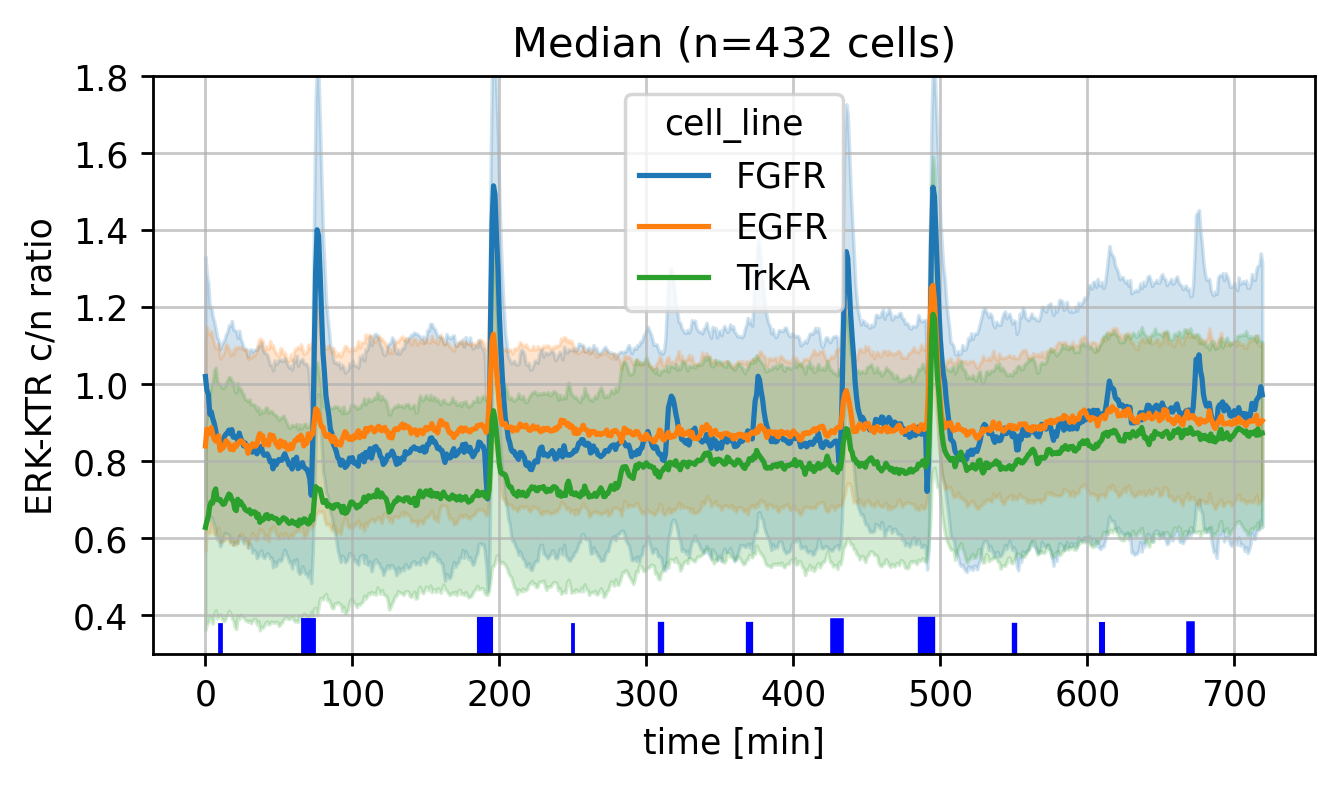

In [21]:
cell_lines = df_plot["cell_line"].unique()
fovs = df_plot["fov"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")
num_cells = df_plot["uid"].nunique()

plt.figure(figsize=(6, 3),dpi = 250)
plt.grid(True, linestyle='-', alpha=0.7)

sns.lineplot(data=df_plot, x='frame', y='cnr_median', estimator = "median", hue = "cell_line", errorbar='sd')

plt.ylabel('ERK-KTR c/n ratio')
plt.xlabel('time [min]')

x_values = [10, 70, 190, 250, 310, 370, 430, 490, 550, 610, 670]
y_values = [50, 500, 1000, 25, 150, 200, 750, 2000, 75, 100, 250]
linewidths = [1.36, 4.27, 4.64, 1.09, 1.82, 2.09, 3.91, 5.00, 1.55, 1.73, 2.45]

for x, lw in zip(x_values, linewidths):
    plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=lw)

plt.ylim(0.3, 1.8)
plt.title(f"Median (n={num_cells} cells)")
plt.savefig(f"figures/Combined_multi_erkktr.png", bbox_inches='tight')
plt.show()

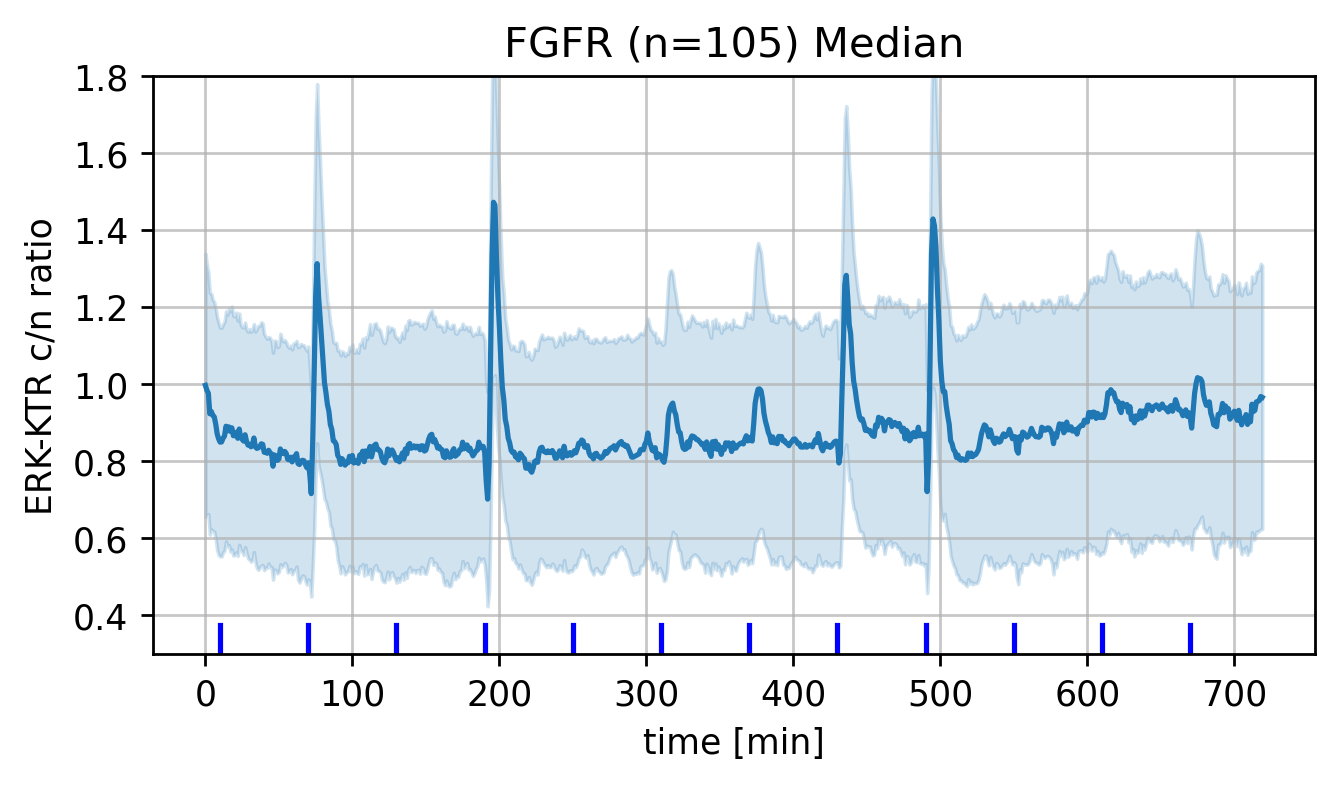

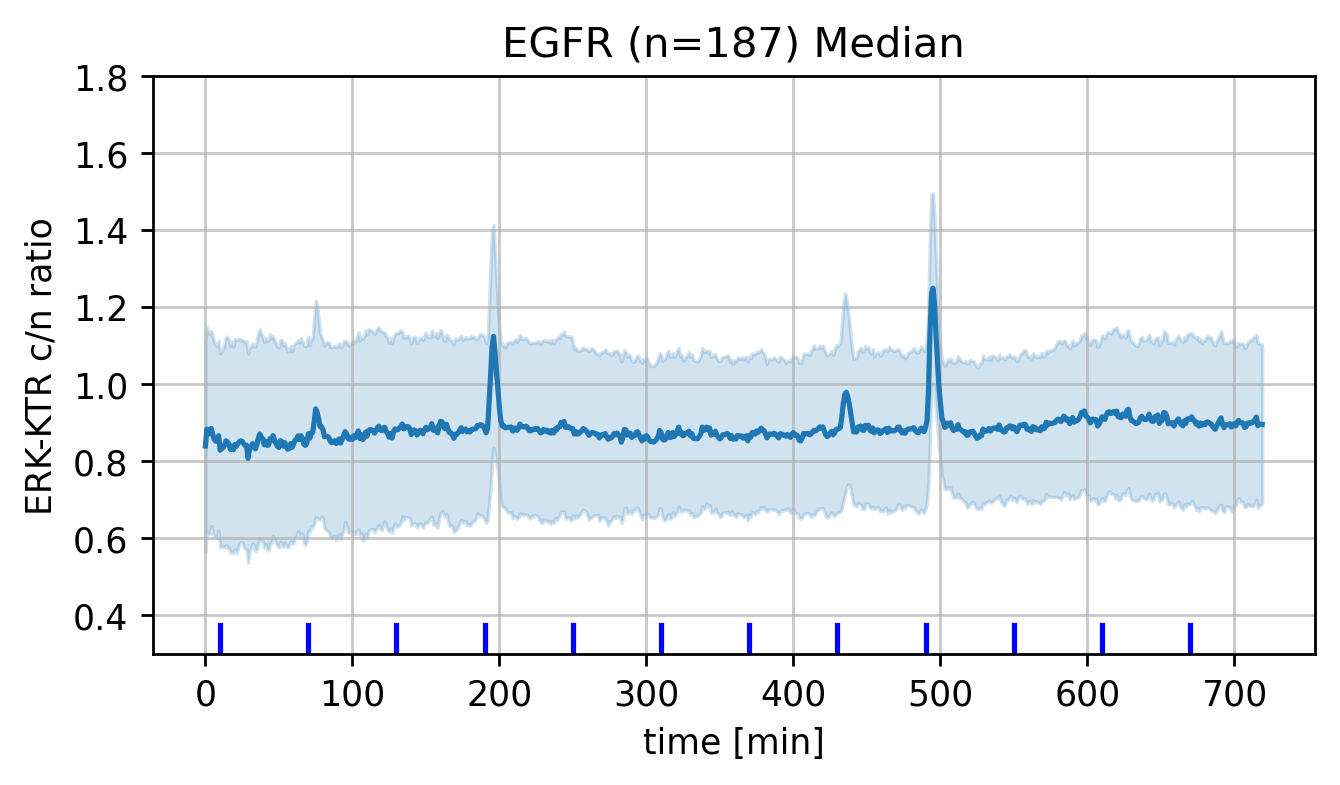

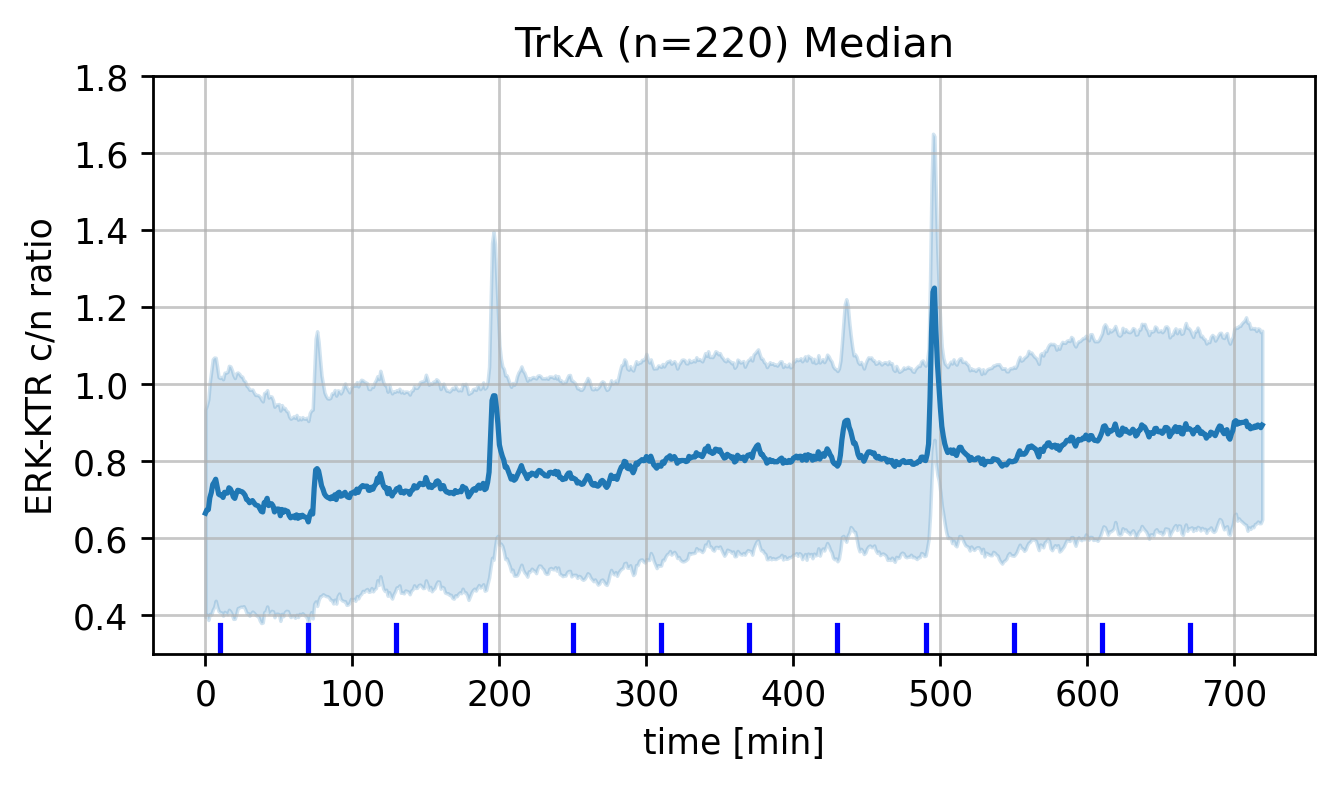

In [7]:
cell_lines = df_plot["cell_line"].unique()
fovs = df_plot["fov"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    plt.figure(figsize=(6, 3),dpi = 250)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()

    plt.grid(True, linestyle='-', alpha=0.7)

    sns.lineplot(data=df_plot.query("cell_line == @cell_line"), x='frame', y='cnr_median', estimator = "median", errorbar='sd')
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = []
    for label in labels:
        num_cells_exposure = df_plot.query("cell_line == @cell_line")["uid"].nunique()
        new_labels.append(f'{label} (n={num_cells_exposure})')
    plt.ylabel('ERK-KTR c/n ratio')
    plt.xlabel('time [min]')

    for x in [10, 70, 130, 190, 250, 310, 370, 430, 490, 550, 610, 670]:
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=1.5)

    plt.ylim(0.3, 1.8)
    plt.title(f"{cell_line} (n={num_cells}) Median")
    plt.legend([], [], frameon=False)
    plt.savefig(f"figures/{cell_line}_multi_erkktr.png", bbox_inches='tight')
    plt.show()

individual traces

<Figure size 10800x3600 with 0 Axes>

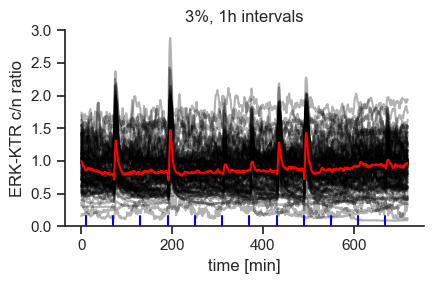

<Figure size 10800x3600 with 0 Axes>

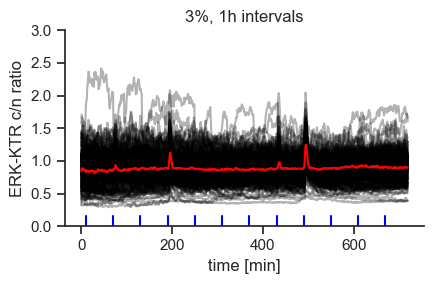

<Figure size 10800x3600 with 0 Axes>

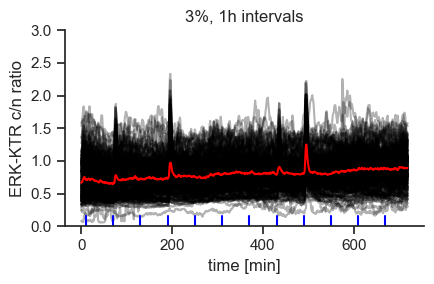

In [8]:
cell_lines = df_plot["cell_line"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    plt.figure(figsize=(18, 6), dpi=600)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()
    sns.set_theme(style="ticks")
    
    # Create the FacetGrid
    g = sns.FacetGrid(
        df_plot.query("cell_line == @cell_line"), 
        height=3, 
        aspect=1.5
    )
    
    # Plot individual traces and mean with confidence interval
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', units="uid", estimator=None, color="black", alpha=0.3)
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', errorbar=('ci', 90), color="red", estimator="median")

    for x in [10, 70, 130, 190, 250, 310, 370, 430, 490, 550, 610, 670]:
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=1.5)
    
    # Set axis labels and titles
    g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
    # Override all subplot titles
    for ax in g.axes.flat:
        ax.set_title("3%, 1h intervals")
    g.set(ylim=(0, 3))

    g.tight_layout()
    
    # Save and show the plot
    plt.savefig(f"figures/{cell_line}_multi_traces_erkktr.png", bbox_inches='tight')
    plt.show()

#### normalised

In [ ]:
cell_lines = df_plot["cell_line"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    plt.figure(figsize=(6, 3),dpi = 250)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()

    sns.lineplot(data=df_plot.query("cell_line == @cell_line"), x='frame', y='cnr_norm', errorbar=('sd'))
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = []
    for label in labels:
        num_cells_exposure = df_plot.query("cell_line == @cell_line and stim_timestep_str == @label")["uid"].nunique()
        new_labels.append(f'{label} (n={num_cells_exposure})')
    plt.ylabel('norm ERK-KTR c/n ratio')
    plt.xlabel('time [min]')
    plt.axvline(x=10, color='black', linestyle='--')
    plt.title(f"{cell_line} (n={num_cells})")
    plt.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=3, frameon=False)
    plt.savefig(f"figures/{cell_line}_multi_norm_erkktr.svg", bbox_inches='tight')
    plt.show()

individual traces

In [ ]:
EXPOSURE_TO_PLOT = 100
cell_lines = df_plot["cell_line"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    plt.figure(figsize=(6, 3), dpi=250)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()
    sns.set_theme(style="ticks")
    
    # Create the FacetGrid
    g = sns.FacetGrid(
        df_plot.query("cell_line == @cell_line"), 
        height=3, 
        aspect=1.5
    )
    
    # Plot individual traces and mean with confidence interval
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_norm', units="uid", estimator=None, color="black", alpha=0.3)
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_norm', errorbar=('ci', 90), color="red", estimator="mean")
    
    # Add vertical lines for stim_timestep
    def add_vertical_lines(data, **kwargs):
        stim_timesteps = data["stim_timestep"].unique()
        for stim_timestep in stim_timesteps[0]:
            plt.axvline(x=stim_timestep, color='blue', linestyle='--', alpha=0.7)
    
    g.map_dataframe(add_vertical_lines)
    
    # Set axis labels and titles
    g.set_axis_labels('time [min]', 'norm. ERK-KTR c/n ratio')
    g.set_titles(col_template="{col_name}")
    g.set(ylim=(0.7, None))
    g.tight_layout()
    
    # Save and show the plot
    plt.savefig(f"figures/{cell_line}_multi_traces_erkktr_norm.png", bbox_inches='tight')
    plt.show()

## Random Subplots

Not Normalized

<Figure size 1500x750 with 0 Axes>

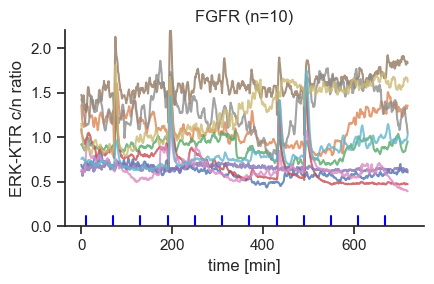

<Figure size 1500x750 with 0 Axes>

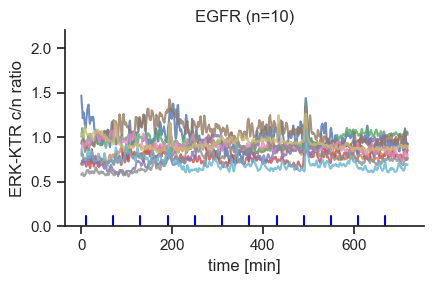

<Figure size 1500x750 with 0 Axes>

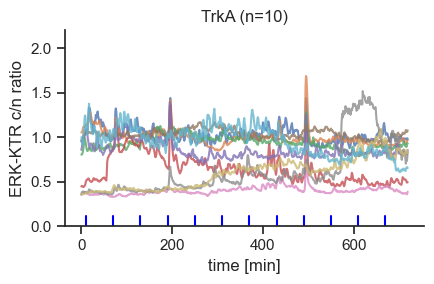

In [9]:
for cell_line in cell_lines: 
    # Filter for this cell line
    df_cell = df_plot.query("cell_line == @cell_line")

    # Get 10 random unique uids
    sampled_uids = np.random.choice(df_cell["uid"].unique(), size=10, replace=False)

    # Filter the data to only these 10 cells
    df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

    plt.figure(figsize=(6, 3), dpi=250)
    sns.set_theme(style="ticks")
    
    g = sns.FacetGrid(
        df_sub, 
        height=3, 
        aspect=1.5
    )

    for x in [10, 70, 130, 190, 250, 310, 370, 430, 490, 550, 610, 670]:
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=1.5)
    
    g.map_dataframe(sns.lineplot, x='frame', y='cnr', hue='uid', estimator=None, alpha=0.8)
    g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
    for ax in g.axes.flat:
        ax.set_title("Ramp 50 ms - 300 ms")
    g.set(ylim=(0, 2.2))
    g.tight_layout()
    
    plt.title(f"{cell_line} (n=10)")
    plt.savefig(f"figures/{cell_line}_10random_erkktr.png", bbox_inches='tight')
    plt.show()

Normalized

<Figure size 1500x750 with 0 Axes>

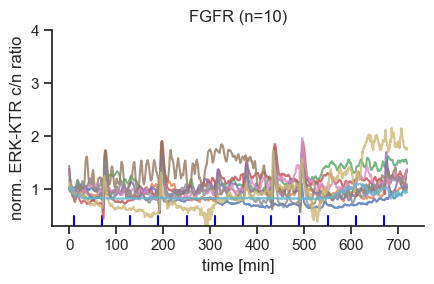

<Figure size 1500x750 with 0 Axes>

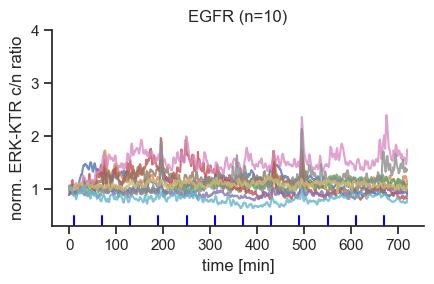

<Figure size 1500x750 with 0 Axes>

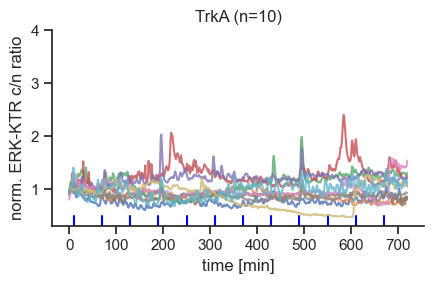

In [15]:
for cell_line in cell_lines: 
    # Filter for this cell line
    df_cell = df_plot.query("cell_line == @cell_line")

    # Get 10 random unique uids
    sampled_uids = np.random.choice(df_cell["uid"].unique(), size=10, replace=False)

    # Filter the data to only these 10 cells
    df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

    plt.figure(figsize=(6, 3), dpi=250)
    sns.set_theme(style="ticks")
    
    g = sns.FacetGrid(
        df_sub, 
        height=3, 
        aspect=1.5
    )

    for x in [10, 70, 130, 190, 250, 310, 370, 430, 490, 550, 610, 670]:
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=1.5)
    
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_norm', hue='uid', estimator=None, alpha=0.8)
    g.set_axis_labels('time [min]', 'norm. ERK-KTR c/n ratio')
    for ax in g.axes.flat:
        ax.set_title("Ramp 50 ms - 300 ms")
    g.set(ylim=(0.3, 4))
    g.tight_layout()
    
    plt.title(f"{cell_line} (n=10)")
    plt.savefig(f"figures/{cell_line}_10random_erkktr_norm.png", bbox_inches='tight')
    plt.show()

## Subplots for each FOV

In [22]:
cell_line_fovs = {
    "FGFR": [0, 1, 2, 3, 4, 5],
    "EGFR": [6, 7, 8, 9, 10, 11],
    "TrkA": [12, 13, 14, 15, 16, 17],
}

In [ ]:
cell_lines = df_plot["cell_line"].unique()
fovs = df_plot["fov"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    for fov in cell_line_fovs[cell_line]:
        plt.figure(figsize=(6, 3),dpi = 250)
        num_cells = df_plot.query("cell_line == @cell_line & fov == @fov")["uid"].nunique()

        plt.grid(True, linestyle='-', alpha=0.7)

        sns.lineplot(data=df_plot.query("cell_line == @cell_line & fov == @fov" ), x='frame', y='cnr_median', estimator = "median", errorbar='sd')
        handles, labels = plt.gca().get_legend_handles_labels()
        new_labels = []
        for label in labels:
            num_cells_exposure = df_plot.query("cell_line == @cell_line & fov == @fov")["uid"].nunique()
            new_labels.append(f'{label} (n={num_cells_exposure})')
        plt.ylabel('ERK-KTR c/n ratio')
        plt.xlabel('time [min]')
   
        for x in [10, 70, 130, 190, 250, 310, 370, 430, 490, 550, 610, 670]:
            plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=1.5)


        plt.ylim(0.3, 1.8)
        plt.title(f"{cell_line} {fov} (n={num_cells}) Median")
        plt.legend([], [], frameon=False)
        plt.savefig(f"figures/{cell_line}_{fov}_multi_erkktr.png", bbox_inches='tight')
        plt.show()

<Figure size 1500x750 with 0 Axes>

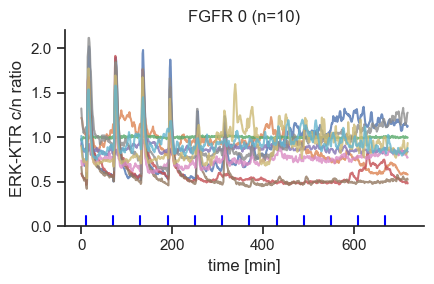

<Figure size 1500x750 with 0 Axes>

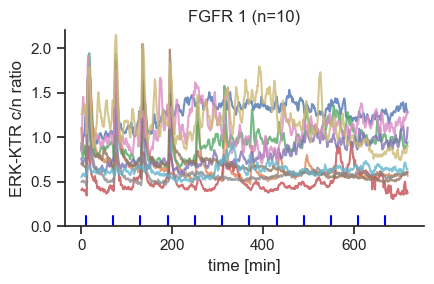

<Figure size 1500x750 with 0 Axes>

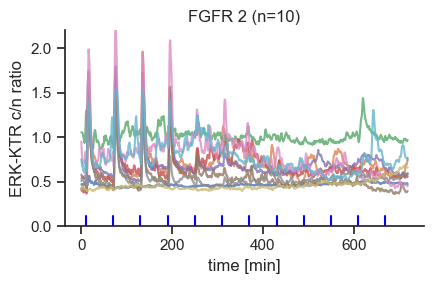

<Figure size 1500x750 with 0 Axes>

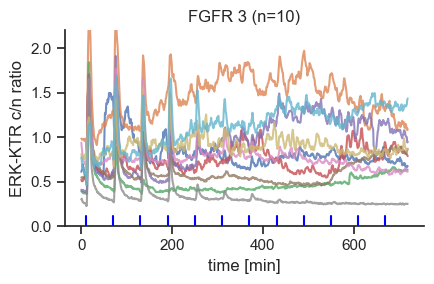

<Figure size 1500x750 with 0 Axes>

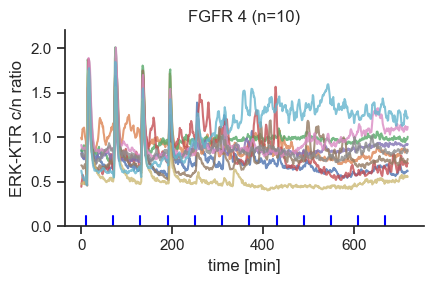

<Figure size 1500x750 with 0 Axes>

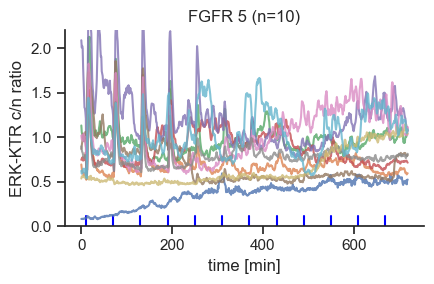

<Figure size 1500x750 with 0 Axes>

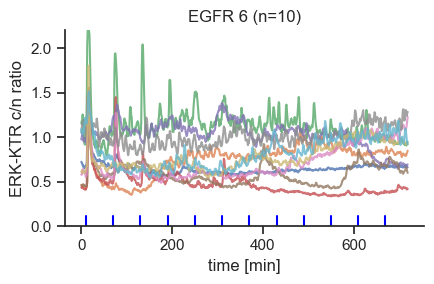

<Figure size 1500x750 with 0 Axes>

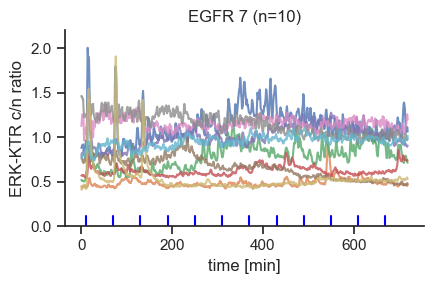

<Figure size 1500x750 with 0 Axes>

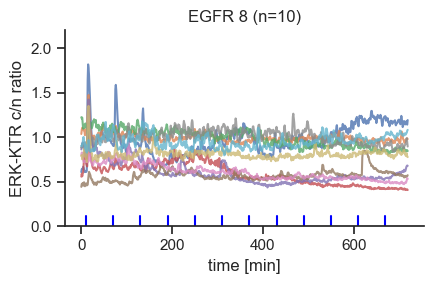

<Figure size 1500x750 with 0 Axes>

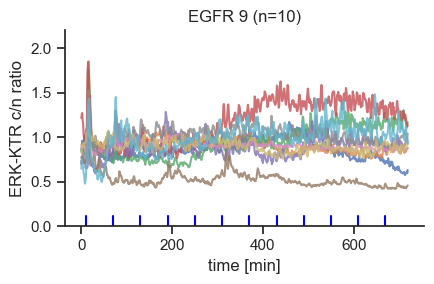

<Figure size 1500x750 with 0 Axes>

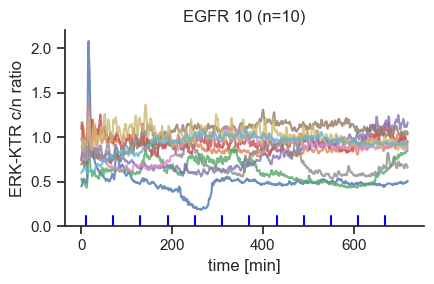

<Figure size 1500x750 with 0 Axes>

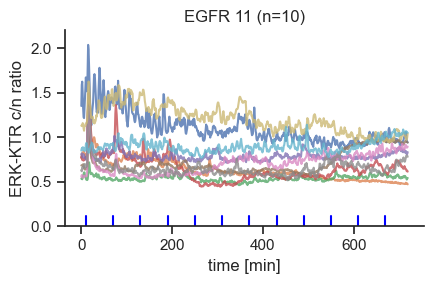

<Figure size 1500x750 with 0 Axes>

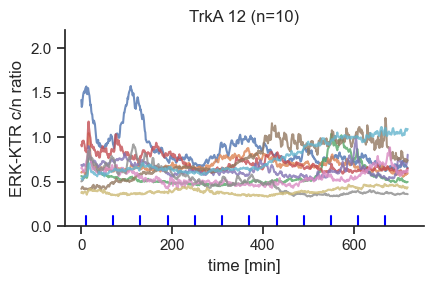

<Figure size 1500x750 with 0 Axes>

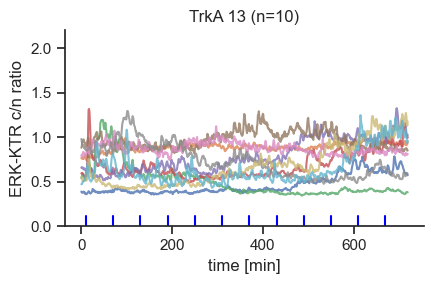

<Figure size 1500x750 with 0 Axes>

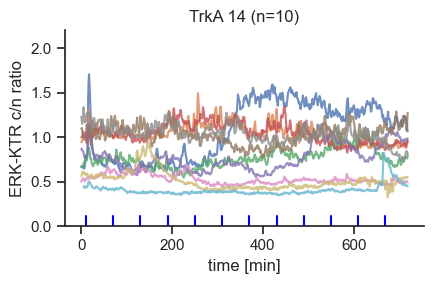

<Figure size 1500x750 with 0 Axes>

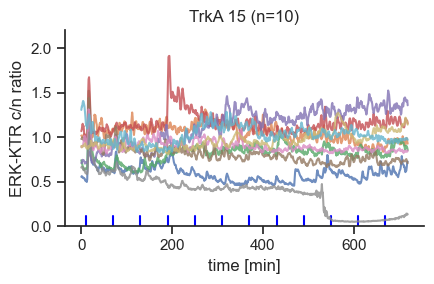

<Figure size 1500x750 with 0 Axes>

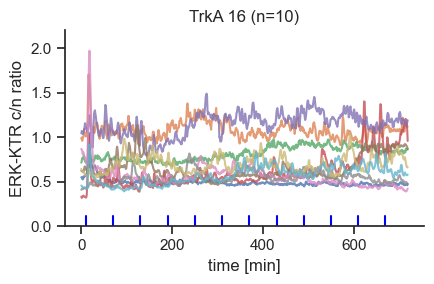

<Figure size 1500x750 with 0 Axes>

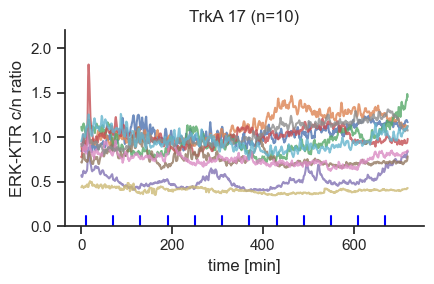

In [23]:
for cell_line in cell_lines: 
    for fov in cell_line_fovs[cell_line]:
        # Filter for this cell line and fov
        df_cell = df_plot.query("cell_line == @cell_line & fov == @fov")

        # Get unique uids
        unique_uids = df_cell["uid"].unique()

        # Skip if less than 10
        if len(unique_uids) < 10:
            print(f"Skipping {cell_line} {fov} (only {len(unique_uids)} cells)")
            continue  

        # Sample 10 random unique uids
        sampled_uids = np.random.choice(unique_uids, size=10, replace=False)

        # Filter the data to only these 10 cells
        df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

        plt.figure(figsize=(6, 3), dpi=250)
        sns.set_theme(style="ticks")
        
        g = sns.FacetGrid(
            df_sub, 
            height=3, 
            aspect=1.5
        )

        for x in [10, 70, 130, 190, 250, 310, 370, 430, 490, 550, 610, 670]:
            plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=1.5)
        
        g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', hue='uid', estimator=None, alpha=0.8)
        g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
        for ax in g.axes.flat:
            ax.set_title("Ramp 50 ms - 300 ms")
        g.set(ylim=(0, 2.2))
        g.tight_layout()
        
        plt.title(f"{cell_line} {fov} (n=10)")
        plt.savefig(f"figures/{cell_line}_{fov}_10random_erkktr.png", bbox_inches='tight')
        plt.show()

In [ ]:
for cell_line in cell_lines: 
    for fov in cell_line_fovs[cell_line]:
        # Filter for this cell line and fov
        df_cell = df_plot.query("cell_line == @cell_line & fov == @fov")

        # Get 10 random unique uids
        sampled_uids = np.random.choice(df_cell["uid"].unique(), size=10, replace=False)

        # Filter the data to only these 10 cells
        df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

        plt.figure(figsize=(6, 3), dpi=250)
        sns.set_theme(style="ticks")
        
        g = sns.FacetGrid(
            df_sub, 
            height=3, 
            aspect=1.5
        )

        x_start = 10
        x_end = 150

        for x in range(x_start, x_end + 1):
            # Normalize x between 0 and 1
            t = (x - x_start) / (x_end - x_start)
            # Map to desired ymax range
            ymax = 0.01 + t * (0.1 - 0.01)
            plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=ymax, linewidth=1)
        
        g.map_dataframe(sns.lineplot, x='frame', y='cnr', hue='uid', estimator=None, alpha=0.8)
        g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
        for ax in g.axes.flat:
            ax.set_title("Ramp 50 ms - 300 ms")
        g.set(ylim=(0, 2.2))
        g.tight_layout()
        
        plt.title(f"{cell_line} {fov} (n=10)")
        plt.savefig(f"figures/{cell_line}_{fov}_10random_erkktr.png", bbox_inches='tight')
        plt.show()

## Clustering